In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast 

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from sklearn.multioutput import MultiOutputClassifier

In [125]:
DATA_PATH = Path("mxmh_cleaned.csv") 
df = pd.read_csv(DATA_PATH)

# convert string representation of lists back to lists
df['genre_list'] = df['genre_list'].apply(ast.literal_eval)

In [126]:
# split features and target
X = df.drop(columns=['genre_list'])
y_raw = df['genre_list']

# multi-label binarization
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(y_raw)
genre_labels = mlb.classes_

print("Genres:", genre_labels)

Genres: ['Classical' 'Country Folk' 'Edm Lofi Vgm' 'Hiphop Rap' 'Jazz' 'Kpop'
 'Latin' 'Pop' 'Randb Gospel' 'Rock Metal']


In [127]:
# identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: Index(['hours_per_day', 'age', 'while_working', 'exploratory',
       'foreign_languages', 'anxiety', 'depression', 'insomnia', 'ocd',
       'freq_hiphop_rap', 'freq_rock_metal', 'freq_edm_lofi_vgm',
       'freq_country_folk', 'freq_randb_gospel', 'freq_classical', 'freq_jazz',
       'freq_pop', 'freq_latin', 'freq_kpop'],
      dtype='object')
Categorical: Index([], dtype='object')


In [128]:
# preprocessing
# numeric_transformer = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="mean")),
#     ("scaler", StandardScaler())
# ])

# categorical_transformer = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("onehot", OneHotEncoder(handle_unknown="ignore"))
# ])

# preprocessor = ColumnTransformer(
#     transformers=[
#         ("num", numeric_transformer, numeric_cols),
#         ("cat", categorical_transformer, categorical_cols)
#     ]
# )

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [129]:
log_reg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("clf", MultiOutputClassifier(
        LogisticRegression(max_iter=5000)
    ))
])

log_reg_pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [130]:
y_pred = log_reg_pipeline.predict(X_test)

macro_f1 = f1_score(y_test, y_pred, average='macro')
micro_f1 = f1_score(y_test, y_pred, average='micro')

print("Macro F1 Score:", macro_f1)
print("Micro F1 Score:", micro_f1)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=genre_labels))

Macro F1 Score: 0.9235621442040067
Micro F1 Score: 0.9443651925820257
Classification Report:
              precision    recall  f1-score   support

   Classical       1.00      0.83      0.91        29
Country Folk       0.94      0.94      0.94        31
Edm Lofi Vgm       0.98      0.92      0.95        51
  Hiphop Rap       0.97      0.88      0.92        33
        Jazz       0.91      0.71      0.80        14
        Kpop       1.00      0.95      0.97        20
       Latin       1.00      0.80      0.89         5
         Pop       0.97      0.95      0.96        66
Randb Gospel       0.96      0.89      0.92        27
  Rock Metal       0.99      0.96      0.98        85

   micro avg       0.97      0.92      0.94       361
   macro avg       0.97      0.88      0.92       361
weighted avg       0.97      0.92      0.94       361
 samples avg       0.95      0.97      0.96       361



c:\Users\lhail\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [131]:
# convert scores per genre 
report = classification_report(
    y_test, y_pred, target_names=genre_labels, output_dict=True
)

f1_scores = {genre: report[genre]['f1-score'] for genre in genre_labels}
precision_scores = {genre: report[genre]['precision'] for genre in genre_labels}
recall_scores = {genre: report[genre]['recall'] for genre in genre_labels}

c:\Users\lhail\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


C:\Users\lhail\AppData\Local\Temp\ipykernel_61508\1182178382.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=f1_serises.values, y=f1_serises.index, palette="viridis")


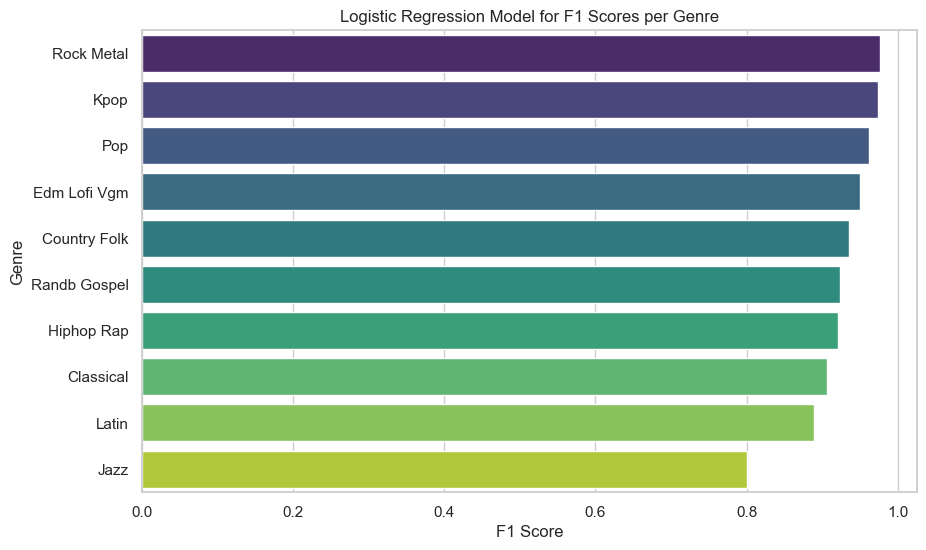

In [132]:
# visualization of F1 scores per genre
f1_serises = pd.Series(f1_scores).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=f1_serises.values, y=f1_serises.index, palette="viridis")
plt.title("Logistic Regression Model for F1 Scores per Genre")
plt.xlabel("F1 Score")
plt.ylabel("Genre")
plt.tight_layout
plt.show()

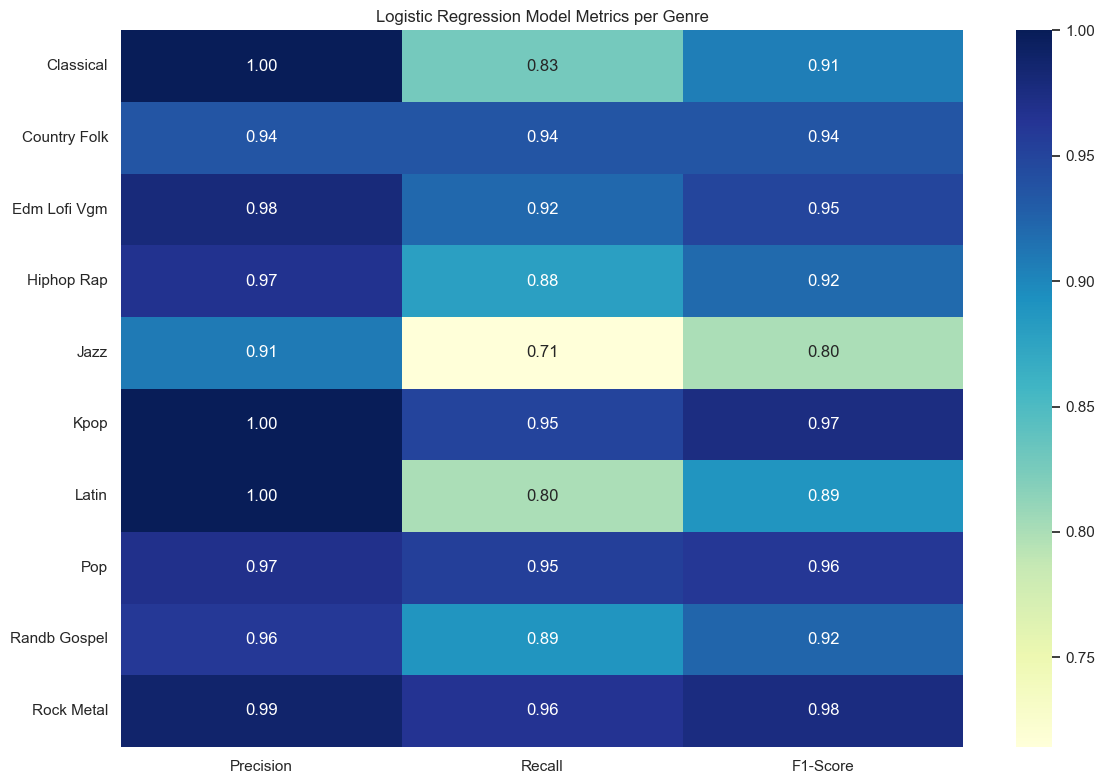

In [133]:
# heatmap of precision, recall, F1-score
metrics_df = pd.DataFrame({
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1-Score': f1_scores
})

plt.figure(figsize=(12, 8))
sns.heatmap(metrics_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Logistic Regression Model Metrics per Genre")
plt.tight_layout()
plt.show()